In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_friedman1
from sklearn.linear_model import Lasso

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

In [ ]:
from sklearn.linear_model import Lasso, Ridge
import numpy as np
from sklearn.datasets import make_friedman1
from tqdm.notebook import tqdm

print(X.shape, y.shape)

def loss(theta):
    return np.mean((X@theta.squeeze() - y)**2)


def gradient(theta, X, y):
    """
    Compute the gradient of the MSE loss function.

    Args:
        theta: parameter vector (shape: (n_features,) or (n_features, 1))
        X: feature matrix (shape: (n_samples, n_features))
        y: target vector (shape: (n_samples,))

    Returns:
        gradient vector (shape: same as theta)
    """
    residual = X @ theta.squeeze() - y
    grad = (2.0 / len(y)) * X.T @ residual

    # Maintain the same shape as input theta
    if theta.ndim == 2:
        grad = grad.reshape(-1, 1)

    return grad


list_of_coefs = []
list_of_scores = []
list_of_model_coefs = []
for _ in tqdm(range(100), leave=False):
    X, y = make_friedman1(n_samples=1000, n_features=10, noise=0.1)

    model = Lasso(alpha=1, fit_intercept=False, max_iter=10000)
    model.fit(X, y)
    list_of_model_coefs.append(model.coef_)

    delta_theta = []
    delta_loss = []
    for rep in range(1000):
        theta_before = np.random.randn(10,1)
        theta_after = theta_before + 1e-2*gradient(theta_before, X, y)
        delta_theta.append((theta_after - theta_before)*30)
        delta_loss.append(loss(theta_after) - loss(theta_before))

    delta_theta = (np.concatenate(delta_theta, axis=1)**2).transpose()
    delta_loss = np.array(delta_loss)    

    clf = Lasso(alpha=1, fit_intercept=False, max_iter=10000)
    clf.fit(delta_theta, delta_loss)

    list_of_coefs.append(clf.coef_)
    list_of_scores.append(clf.score(delta_theta, delta_loss))

list_of_coefs = np.array(list_of_coefs)
list_of_scores = np.array(list_of_scores)
list_of_model_coefs = np.array(list_of_model_coefs)

In [ ]:
list_of_coefs += np.random.randn(*list_of_coefs.shape) * 1e-2
list_of_model_coefs += np.random.randn(*list_of_model_coefs.shape) * 1e-2
print(np.min(list_of_scores))

<Figure size 640x480 with 0 Axes>

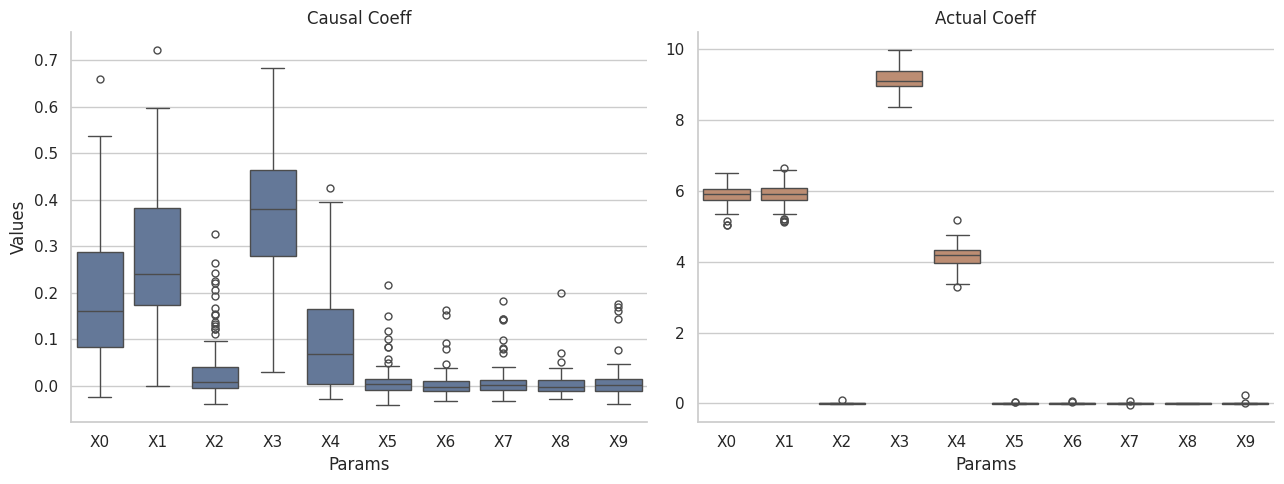

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

desaturated_deep = sns.color_palette("deep", as_cmap=False, desat=0.7)  # 0.7 = 70% saturation
sns.set_theme(style="whitegrid", palette=desaturated_deep)

arr1 = []
arr2 = []
arr3 = []
for i in range(10):
    tmp = np.concatenate([list_of_coefs[:, i], list_of_model_coefs[:, i]])
    arr1.append(tmp)
    arr2.append(i * np.ones(len(tmp)))
    arr3.append(np.concatenate([np.zeros(len(list_of_coefs)), np.ones(len(list_of_coefs))]))
arr1 = np.concatenate(arr1)
arr2 = np.concatenate(arr2)
arr3 = np.concatenate(arr3)

df = pd.DataFrame({"Values": arr1, "Params": arr2, "Flag": arr3})
for i in range(10):
    df["Params"] = df["Params"].replace(i, f"X{i}")
df["Flag"] = df["Flag"].replace(0, "Causal Coeff")
df["Flag"] = df["Flag"].replace(1, "Actual Coeff")

plt.figure()
g = sns.catplot(
    data=df,
    x="Params",
    y="Values",
    hue="Flag",
    col="Flag",
    kind="box",
    sharey=False,
    legend=False,
    aspect=1.3,
)
g.fig.subplots_adjust(wspace=0.6)
titles = ["Causal Coeff", "Actual Coeff"]
for ax, title in zip(g.axes.flat, titles):
    ax.set_title(title)
plt.tight_layout()
plt.savefig("./figv3_1e.png")

In [20]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# desaturated_deep = sns.color_palette("deep", as_cmap=False, desat=0.7)  # 0.7 = 70% saturation
# sns.set_theme(style="whitegrid", palette=desaturated_deep)


# arr1 = np.concatenate([list_of_coefs[:,4], list_of_coefs[:, 6]])
# arr2 = np.concatenate([np.zeros(len(list_of_coefs)), np.ones(len(list_of_coefs))])

# df = pd.DataFrame({"Values": arr1, "Params": arr2})
# df["Params"] = df["Params"].replace(0, "Important")
# df["Params"] = df["Params"].replace(1, "Not-Important")


# # plot the distribution of the important and unimportant parameters on the same plot
# plt.figure(figsize=(10, 5))
# sns.kdeplot(data=df, x="Values", hue="Params", common_norm=True, fill=True)

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))

# first hue
mask_a = df["hue_var"] == "A"
sns.boxplot(
    data=df[mask_a], x="category", y="value", color="steelblue", width=0.35, dodge=False, ax=ax
)

# second hue on a twin y-axis
ax2 = ax.twinx()
mask_b = ~mask_a
sns.boxplot(
    data=df[mask_b], x="category", y="value", color="indianred", width=0.35, dodge=False, ax=ax2
)

# shift the second set sideways so the boxes don’t sit on top of each other
for artists in ax2.containers:
    for patch in artists:
        patch.set_x(patch.get_x() + patch.get_width())  # nudge right

# tidy up
ax2.set_ylabel("value (hue B)")
ax.set_ylabel("value (hue A)")
ax2.grid(False)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="steelblue"),
        plt.Rectangle((0, 0), 1, 1, color="indianred"),
    ],
    labels=["A", "B"],
)
plt.show()